
=== Simulated Data Table ===
   Session  Completion_Time_s  Difficulty_Level  SSVEP_Amblyopic_uV  \
0        1                120                 5               2.549   
1        2                110                10               2.883   
2        3                100                18               3.171   
3        4                 90                25               3.342   

   SSVEP_Fellow_uV    AIR  
0            3.514  0.725  
1            3.489  0.826  
2            3.544  0.895  
3            3.502  0.954  


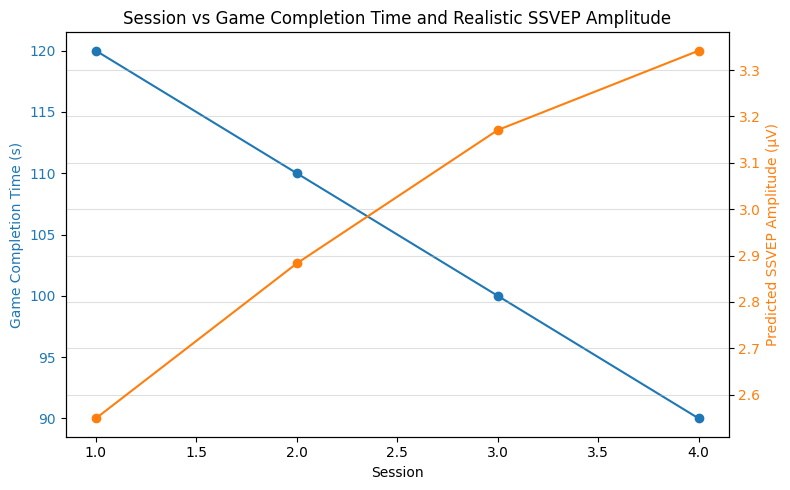

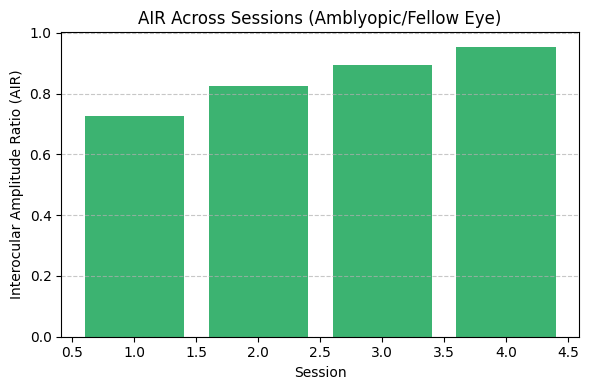

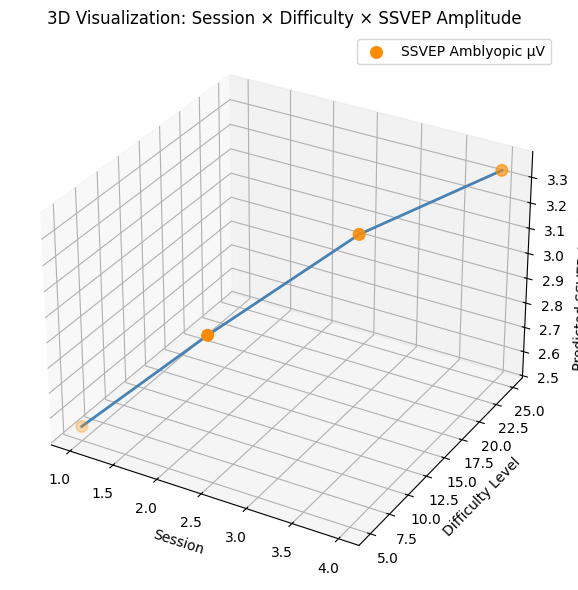


=== Regression Coefficients ===
[Completion Time, Difficulty] = [-0.05215588 -0.03750787], Intercept = 9.006


In [ ]:


import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from sklearn.linear_model import LinearRegression


sessions = np.array([1, 2, 3, 4])              # Gameplay sessions
completion_time = np.array([120, 110, 100, 90])  # Time (seconds)
difficulty = np.array([5, 10, 18, 25])           # Increasing difficulty levels

# EEG Baseline parameters
A0_amb, A0_fellow = 2.5, 3.5                     # Baseline amplitudes (µV)
gain_max = 0.25                                  # Max theoretical improvement (25%)
difficulty_scale = 0.008                         # Weight of difficulty impact
noise_level = 0.05                               # Random EEG variability (µV)


p = (completion_time[0] - completion_time) / (completion_time[0] - completion_time[-1])
p = np.clip(p, 0, 1)  # keep values between 0–1


ssvep_amb = A0_amb * (1 + gain_max * np.sqrt(p)) \
             + (difficulty * difficulty_scale) \
             + np.random.normal(0, noise_level, size=len(sessions))


ssvep_fellow = np.full_like(ssvep_amb, A0_fellow) \
               + np.random.normal(0, 0.02, size=len(sessions))


air = ssvep_amb / ssvep_fellow


df = pd.DataFrame({
    "Session": sessions,
    "Completion_Time_s": completion_time,
    "Difficulty_Level": difficulty,
    "SSVEP_Amblyopic_uV": ssvep_amb,
    "SSVEP_Fellow_uV": ssvep_fellow,
    "AIR": air
})

print("\n=== Simulated Data Table ===")
print(df.round(3))


fig, ax1 = plt.subplots(figsize=(8, 5))
ax1.plot(df["Session"], df["Completion_Time_s"], color='tab:blue', marker='o', label="Completion Time (s)")
ax1.set_xlabel("Session")
ax1.set_ylabel("Game Completion Time (s)", color='tab:blue')
ax1.tick_params(axis='y', labelcolor='tab:blue')

ax2 = ax1.twinx()
ax2.plot(df["Session"], df["SSVEP_Amblyopic_uV"], color='tab:orange', marker='o', label="SSVEP Amplitude (µV)")
ax2.set_ylabel("Predicted SSVEP Amplitude (µV)", color='tab:orange')
ax2.tick_params(axis='y', labelcolor='tab:orange')

plt.title("Session vs Game Completion Time and Realistic SSVEP Amplitude")
fig.tight_layout()
plt.grid(True, alpha=0.4)
plt.show()


plt.figure(figsize=(6, 4))
plt.bar(df["Session"], df["AIR"], color='mediumseagreen')
plt.xlabel("Session")
plt.ylabel("Interocular Amplitude Ratio (AIR)")
plt.title("AIR Across Sessions (Amblyopic/Fellow Eye)")
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection='3d')


ax.scatter(sessions, difficulty, ssvep_amb, color='darkorange', s=70, label="SSVEP Amblyopic µV")
ax.plot(sessions, difficulty, ssvep_amb, color='steelblue', linewidth=2)


ax.set_xlabel('Session')
ax.set_ylabel('Difficulty Level')
ax.set_zlabel('Predicted SSVEP Amplitude (µV)')
ax.set_title('3D Visualization: Session × Difficulty × SSVEP Amplitude')
ax.legend()

plt.tight_layout()
plt.show()


X = np.column_stack([completion_time, difficulty])
y = ssvep_amb
reg = LinearRegression().fit(X, y)
print("\n=== Regression Coefficients ===")
print(f"[Completion Time, Difficulty] = {reg.coef_}, Intercept = {reg.intercept_:.3f}")
